In [2]:
# Verifica la versión de Python instalada en el entorno
!python --version

Python 3.14.2


In [30]:
# Importa las librerías necesarias para descargar, manipular y visualizar los datos
import os  # Permite interactuar con el sistema de archivos
import tarfile  # Maneja archivos comprimidos en formato .tgz
import urllib  # Permite descargar archivos desde internet
import matplotlib.pyplot as plt  # Para crear gráficos y visualizaciones
import pandas as pd  # Para trabajar con tablas y DataFrames
import numpy as np  # Para operaciones numéricas y aleatorias
from zlib import crc32  # Genera un checksum para separar datos de forma estable
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit  # Herramientas para dividir datos en entrenamiento y prueba
from pandas.plotting import scatter_matrix  # Para crear matrices de dispersión
from sklearn.impute import SimpleImputer  # Para manejar valores faltantes en los datos

# Define la URL base y la ruta donde se almacenará el dataset
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

# Función para descargar y descomprimir el dataset de vivienda
def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    os.makedirs(housing_path, exist_ok=True)  # Crea la carpeta si no existe
    tgz_path = os.path.join(housing_path, "housing.tgz")  # Ruta del archivo comprimido
    urllib.request.urlretrieve(housing_url, tgz_path)  # Descarga el archivo desde la URL
    housing_tgz = tarfile.open(tgz_path)  # Abre el archivo .tgz
    housing_tgz.extractall(path=housing_path)  # Extrae su contenido en la carpeta destino
    housing_tgz.close()  # Cierra el archivo comprimido

# Ejecuta la función para obtener el dataset
fetch_housing_data()

In [4]:
# Función para cargar los datos desde el archivo CSV
def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")  # Construye la ruta completa del archivo CSV
    return pd.read_csv(csv_path)  # Lee el archivo CSV y lo convierte en un DataFrame

# Carga el dataset en una variable llamada housing
housing = load_housing_data()

# Muestra las primeras filas del DataFrame para comprobar su contenido
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
# Muestra información general del dataset: columnas, tipos de datos y valores nulos
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [6]:
# Muestra cuántas veces aparece cada categoría en la columna ocean_proximity
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [7]:
# Resume estadísticamente las columnas numéricas del dataset
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


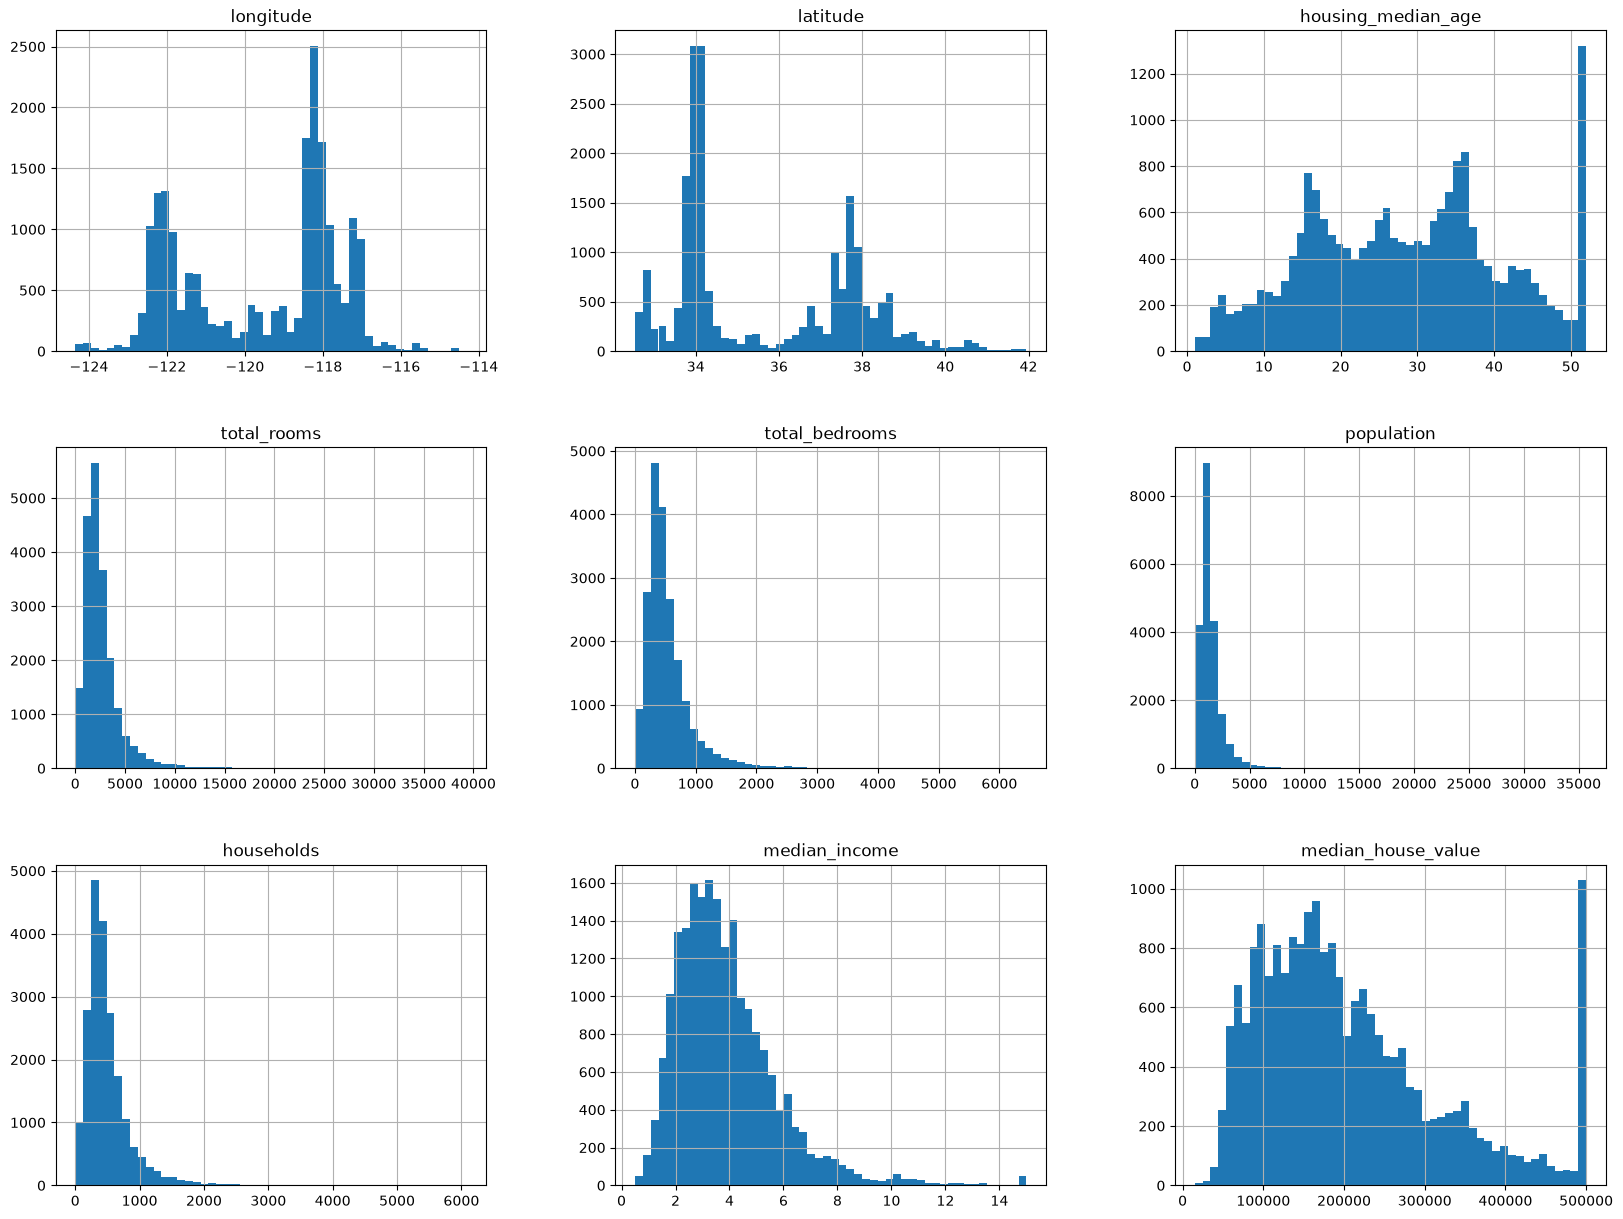

In [8]:
# Genera histogramas de todas las columnas numéricas para inspeccionar su distribución
housing.hist(bins=50, figsize=(20,15))  # Usa 50 bins y un tamaño grande para la visualización
plt.show()  # Muestra la figura creada

In [9]:
# Separa el conjunto de datos en entrenamiento y prueba de forma aleatoria
# La función mezcla los índices y toma un porcentaje para prueba

def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))  # Genera un orden aleatorio de los índices
    test_set_size = int(len(data) * test_ratio)  # Calcula cuántas filas irán al conjunto de prueba
    test_indices = shuffled_indices[:test_set_size]  # Selecciona las primeras filas para prueba
    train_indices = shuffled_indices[test_set_size:]  # El resto va a entrenamiento
    return data.iloc[train_indices], data.iloc[test_indices]  # Devuelve ambos subconjuntos

# Ejecuta la función para dividir los datos con una proporción del 20%
train_set, test_set = split_train_test(housing, 0.2)

# Muestra la cantidad de filas en cada conjunto
len(train_set), len(test_set)

(16512, 4128)

In [11]:
# Separa los datos usando un identificador estable basado en el índice de cada fila
# Esto evita que la división cambie si se vuelve a ejecutar el código

def test_set_check(identifier, test_ratio):
    return crc32(np.int64(identifier)) & 0xffffffff < test_ratio * 2**32  # Determina si una fila entra al conjunto de prueba

# Función que usa la columna de identificadores para separar los datos
def split_train_test_by_id(data, test_ratio, id_column):
    ids = data[id_column]  # Obtiene la columna de identificadores
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio))  # Aplica la condición a cada fila
    return data.loc[~in_test_set], data.loc[in_test_set]  # Devuelve train y test según el resultado

# Añade una columna de id basada en el índice original del DataFrame
housing_with_id = housing.reset_index()

# Divide los datos usando la columna "id"
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "index")

In [12]:
# Crea un identificador a partir de la latitud y longitud para separar los datos de forma consistente
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]  # Combina coordenadas en un valor único

# Vuelve a dividir el dataset usando ese identificador nuevo
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "id")

In [13]:
# Usa la función de scikit-learn para dividir los datos en entrenamiento y prueba
# random_state garantiza que la separación sea reproducible
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

<Axes: >

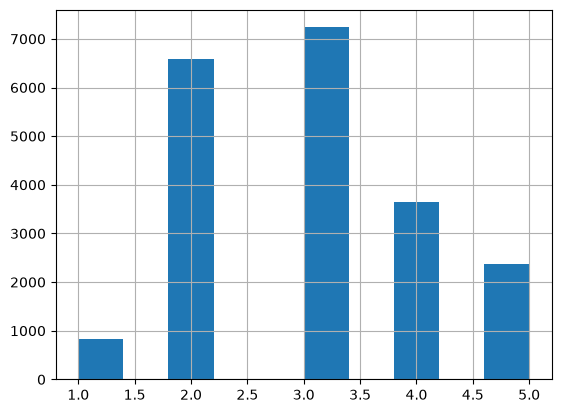

In [14]:
# Crea una categoría de ingresos basada en el rango de median_income
housing['income_cat'] = pd.cut(
    housing['median_income'],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],  # Define los rangos de ingresos
    labels=[1, 2, 3, 4, 5]  # Asigna una etiqueta a cada intervalo
)

# Muestra un histograma de la nueva columna para verificar la distribución
housing['income_cat'].hist()

In [15]:
# Aplica una división estratificada para conservar la proporción de categorías en train y test
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing['income_cat']):
    strat_train_set = housing.loc[train_index]  # Filtra las filas para entrenamiento
    strat_test_set = housing.loc[test_index]  # Filtra las filas para prueba

In [16]:
# Muestra la proporción de cada categoría en el conjunto de entrenamiento
strat_train_set['income_cat'].value_counts() / len(strat_train_set)

income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64

In [17]:
# Elimina la columna auxiliar income_cat de los conjuntos para no dejarla como característica
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [18]:
# Crea una copia del conjunto de entrenamiento para trabajar sobre él sin modificar el original
housing = strat_train_set.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

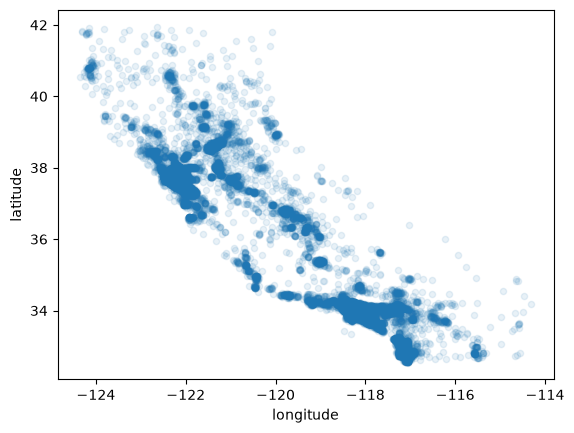

In [19]:
# Dibuja un gráfico de dispersión entre latitud y longitud para inspeccionar la distribución geográfica
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

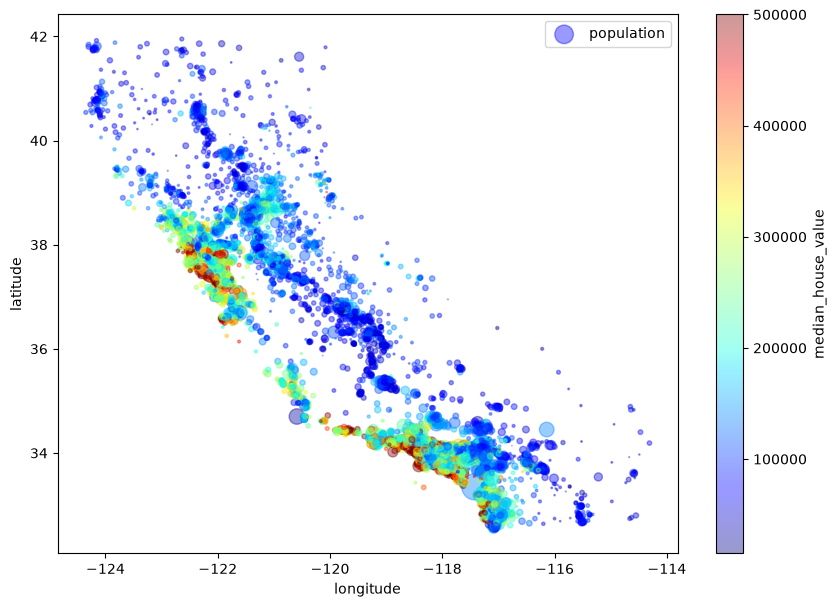

In [20]:
# Genera un mapa de calor geográfico donde el tamaño del punto representa la población y el color el precio de la vivienda
housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.4,
    s=housing["population"]/100,  # El tamaño del punto depende de la población
    label="population",
    figsize=(10,7),
    c="median_house_value",  # El color representa el valor medio de la vivienda
    cmap=plt.get_cmap("jet"),  # Usa una paleta de colores para diferenciar valores
    colorbar=True
)

plt.legend()  # Muestra la leyenda del gráfico

In [22]:
# Calcula la matriz de correlación entre las columnas numéricas del dataset
corr_matrix = housing.select_dtypes(include=[np.number]).corr()

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

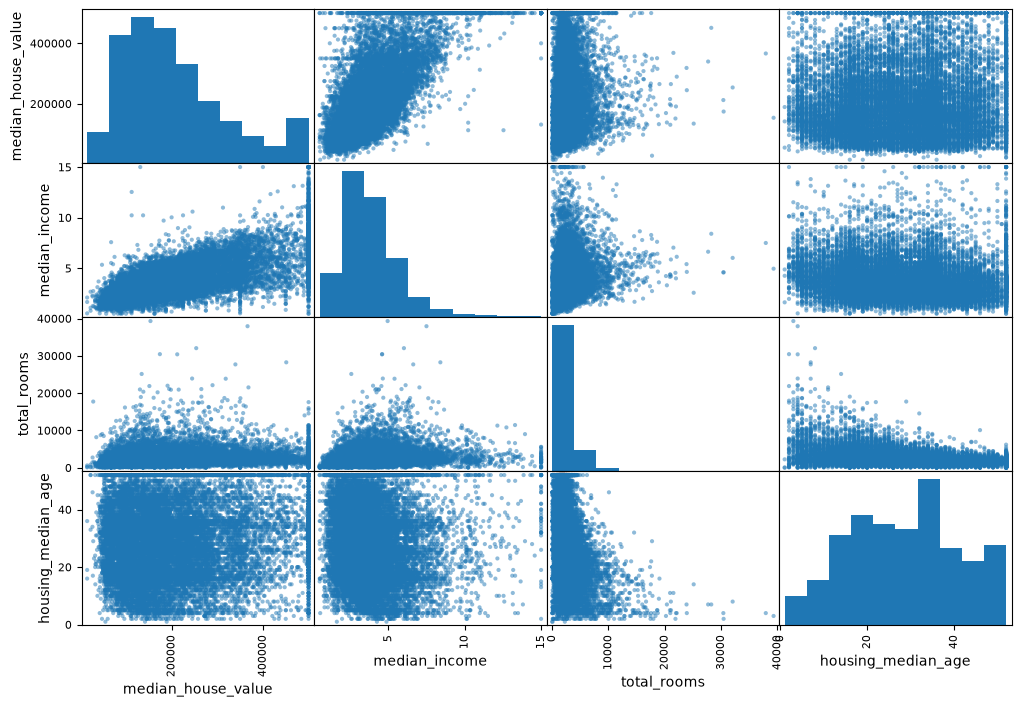

In [25]:
# Selecciona algunas columnas clave para visualizar relaciones entre variables
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))

In [26]:
# Crea nuevas características que capturan ratios útiles para el modelo
housing['rooms_per_household'] = housing['total_rooms']/housing['households']
housing['bedrooms_per_room'] = housing['total_bedrooms']/housing['total_rooms']
housing['population_per_household'] = housing['population']/housing['households']

# Muestra la correlación de cada variable con el precio de la vivienda
corr_matrix = housing.select_dtypes(include=[np.number]).corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64

In [35]:
# Separa la variable objetivo de las características del conjunto de entrenamiento
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [36]:
# Prueba formas de manejar la columna total_bedrooms, que puede tener valores faltantes
#housing.dropna(subset=['total_bedrooms'])
#housing.drop("total_bedrooms", axis=1)
median = housing["total_bedrooms"].median()
housing["total_bedrooms"].fillna(median, inplace=True)

C:\Users\elias\AppData\Local\Temp\ipykernel_35984\200244865.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  housing["total_bedrooms"].fillna(median, inplace=True)


12655     797.0
15502     855.0
2908      310.0
14053     519.0
20496     646.0
          ...  
15174    1231.0
12661    1422.0
19263     166.0
19140     580.0
19773     222.0
Name: total_bedrooms, Length: 16512, dtype: float64

In [37]:
# Usa un imputador para completar valores faltantes con la mediana de cada columna numérica
imputer = SimpleImputer(strategy="median")
housing_num = housing.drop("ocean_proximity", axis=1)
imputer.fit(housing_num)

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['longitude','latitude','housing_median_age',...,'population','households', 'median_income']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](8,)","[-118.51, 34.26, 29. ,...,1164. , 408. , 3.54]"


In [32]:
imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [33]:
housing_num.median().values

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [ ]:
# Transforma los datos numéricos usando el imputador para reemplazar valores faltantes
x = imputer.transform(housing_num)

In [ ]:
# Crea un DataFrame con los datos transformados, manteniendo las columnas y el índice original
housing_tr = pd.DataFrame(x, columns=housing_num.columns, index=housing.index)

In [34]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(10)

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
1481,NEAR BAY
18125,<1H OCEAN
5830,<1H OCEAN
17989,<1H OCEAN
4861,<1H OCEAN
